In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from Calculation_functions_V2_NIBI import proportions_from_filename, metrics_table

In [2]:
colors = [(0, 0, 0, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)

In [3]:
values_cores = np.array([711, 1810, 12700, 1120, 927, 778, 347]) # pg / g
NSoG = values_cores[0]
SSoGa_0 = values_cores[4]
SSoGa_1 = values_cores[6]
IPlume_0 = values_cores[2]
IPlume_1 = values_cores[3]
HWSound = values_cores[1]
SSoGb = values_cores[5]
#
obs = [NSoG, SSoGa_0, SSoGa_1, SSoGb, IPlume_0, IPlume_1, HWSound]
#
obsi = obs / np.sum(values_cores)

In [4]:
from Region_functions_V3_NIBI import polygon_definition_data_colloidal, volumes_50m_bottom, polygon_lon_lat_N1, polygon_lon_lat_S1
volumes_regions, regions_names = volumes_50m_bottom()
volume_S1 = volumes_regions[4]# + volumes_regions[5]
volume_N1 = volumes_regions[0]

# Reference N1/S1 1 year Run (ratio to change)

In [ ]:
#data_2007_reference = xr.open_dataset('/home/vicentev/scratch/vicentev/long_term_simulation.nc').isel(obs = slice(None, 4380))
data_2007_reference = xr.open_dataset('/home/vicentev/scratch/vicentev/long_term_simulation.nc').isel(obs = slice(4008, 4380))
#
counts_S1_ref = polygon_definition_data_colloidal(data_2007_reference, polygon_lon_lat_S1)
counts_N1_ref = polygon_definition_data_colloidal(data_2007_reference, polygon_lon_lat_N1)
#
sum_concentration_N1_ref = np.sum(counts_N1_ref) / volume_N1
#
sum_concentration_S1_ref = np.sum(counts_S1_ref) / volume_S1
#
print('Ratio (S1 / N1) new Version', sum_concentration_S1_ref/sum_concentration_N1_ref)

NameError: name 'xr' is not defined

In [165]:
print('Concentration at S1 (50m - bottom) = ', sum_concentration_S1_ref)

Concentration at S1 (50m - bottom) =  count    0.00001
dtype: float64


In [167]:
min_ratio = (sum_concentration_S1_ref/sum_concentration_N1_ref) * 4
max_ratio = (sum_concentration_S1_ref/sum_concentration_N1_ref) * 15
print('Max ratio to aim: ', max_ratio.iloc[0])
print('Min ratio to aim: ', min_ratio.iloc[0])

Max ratio to aim:  31.790305118426275
Min ratio to aim:  8.477414698247006


In [166]:
target_concentration = sum_concentration_S1_ref * 9
print('Target concentration: ', target_concentration)

Target concentration:  count    0.00009
dtype: float64


# Tuning/Sensitivity Visualization

# Adsorption

- 1 / 20 days
- 1 / 60 days
- 1 / 100 days

In [9]:
adsorption_testing_files = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_2_days_tau_0_0075.zarr',
                           '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_2_days_tau_0_0085.zarr',
                           '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_2_days_tau_0_01.zarr']

In [5]:
run_adsorption_20_days = proportions_from_filename(filename = adsorption_testing_files[0])
run_adsorption_60_days = proportions_from_filename(filename = adsorption_testing_files[1])
run_adsorption_100_days = proportions_from_filename(filename = adsorption_testing_files[2])
#
table_adsorption_20_days, sed_conc_adsorption_20_days  = metrics_table(filename = adsorption_testing_files[0], plot = False)
table_adsorption_60_days, sed_conc_adsorption_60_days  = metrics_table(filename = adsorption_testing_files[1], plot = False)
table_adsorption_100_days, sed_conc_adsorption_100_days  = metrics_table(filename = adsorption_testing_files[2], plot = False)

/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


KeyboardInterrupt: 

In [ ]:
water_adsorption_20_days, sediment_adsorption_20_days =  run_adsorption_20_days['Sewage W.C.'] + run_adsorption_20_days['Colloidal W.C.'] + run_adsorption_20_days['Marine W.C.'] , run_adsorption_20_days['Sewage S.'] + run_adsorption_20_days['Colloidal S.'] + run_adsorption_20_days['Marine S.']
water_adsorption_60_days, sediment_adsorption_60_days =  run_adsorption_60_days['Sewage W.C.'] + run_adsorption_60_days['Colloidal W.C.'] + run_adsorption_60_days['Marine W.C.'] , run_adsorption_60_days['Sewage S.'] + run_adsorption_60_days['Colloidal S.'] + run_adsorption_60_days['Marine S.']
water_adsorption_100_days, sediment_adsorption_100_days =  run_adsorption_100_days['Sewage W.C.'] + run_adsorption_100_days['Colloidal W.C.'] + run_adsorption_100_days['Marine W.C.'] , run_adsorption_100_days['Sewage S.'] + run_adsorption_100_days['Colloidal S.'] + run_adsorption_100_days['Marine S.']

In [ ]:
#
data_adsorption_20_days = xr.open_zarr(adsorption_testing_files[0])
wc_adsorption_20_days = data_adsorption_20_days.where((data_adsorption_20_days.status < 4)& (data_adsorption_20_days.status > 0))
sed_adsorption_20_days = data_adsorption_20_days.where((data_adsorption_20_days.status > 10))
data_adsorption_60_days = xr.open_zarr(adsorption_testing_files[1])
wc_adsorption_60_days = data_adsorption_60_days.where((data_adsorption_60_days.status < 4)& (data_adsorption_60_days.status > 0))
sed_adsorption_60_days = data_adsorption_60_days.where((data_adsorption_60_days.status > 10))
data_adsorption_100_days = xr.open_zarr(adsorption_testing_files[2])
wc_adsorption_100_days = data_adsorption_100_days.where((data_adsorption_100_days.status < 4)& (data_adsorption_100_days.status > 0))
sed_adsorption_100_days = data_adsorption_100_days.where((data_adsorption_100_days.status > 10))
#

/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/matplotlib/collections.py:200: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  offsets = np.asanyarray(offsets, float)


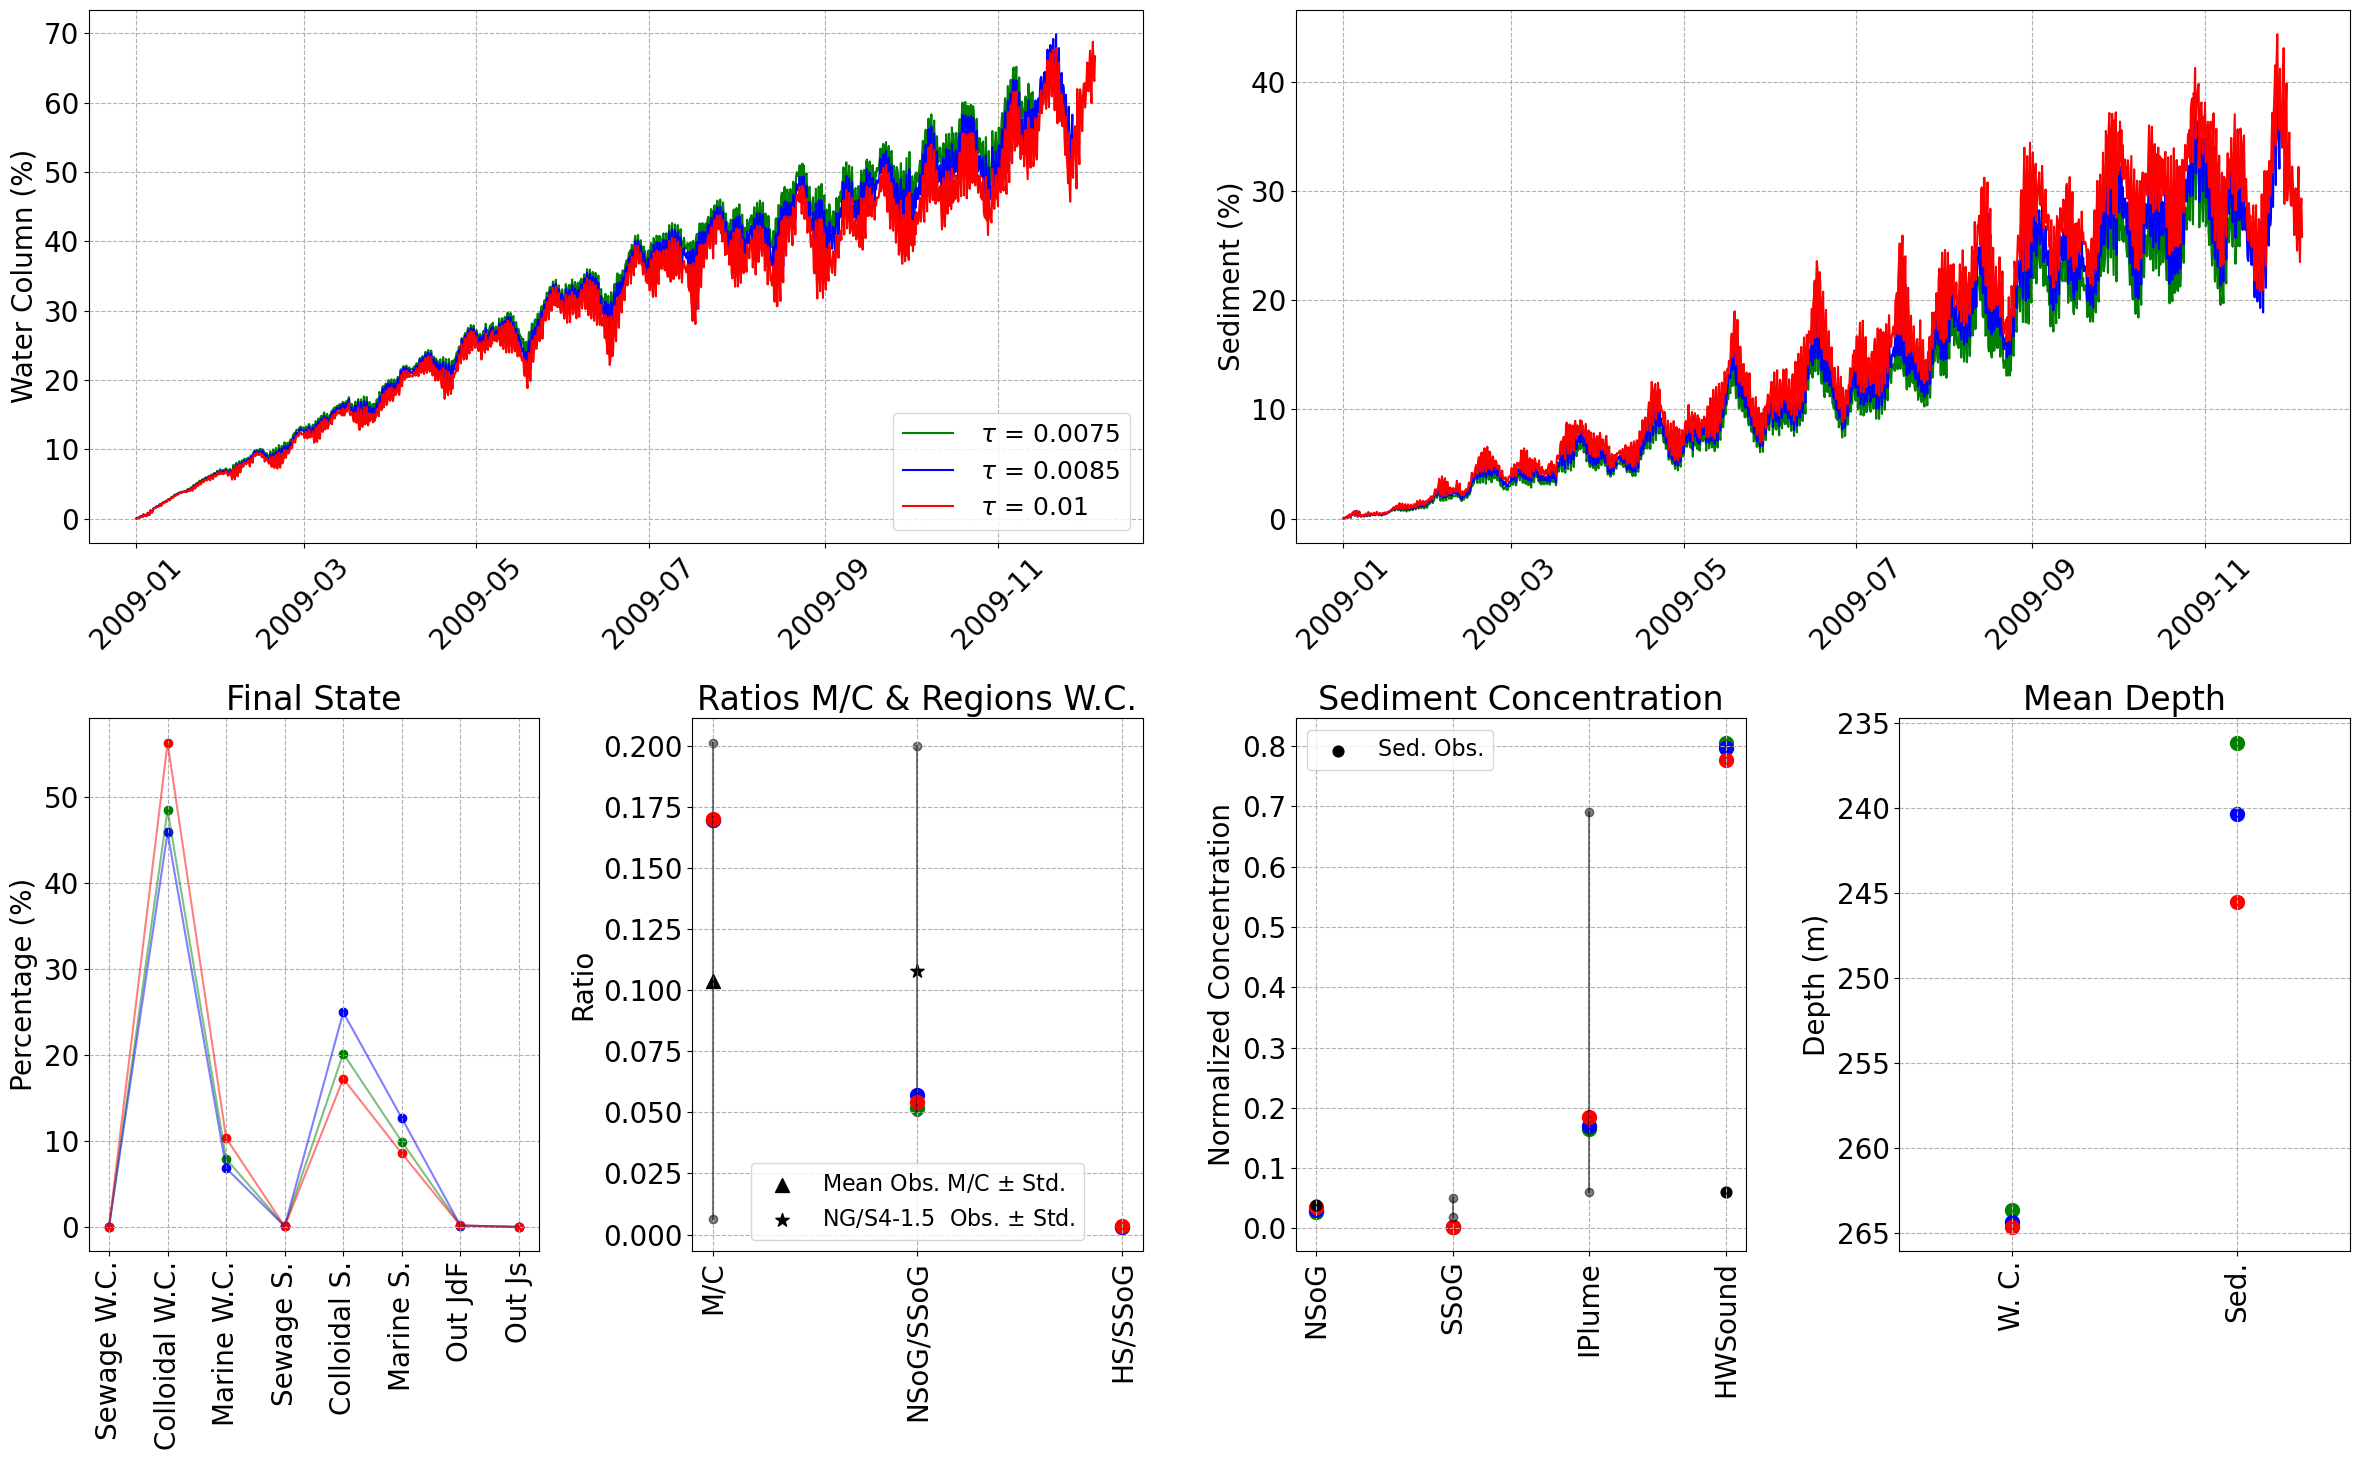

In [ ]:
plt.rcParams.update({'font.size': 20})

fig = plt.figure(figsize=(24, 15))
gs = gridspec.GridSpec(2, 8, height_ratios=[1,1])

# === Top row (2 panels) ===
ax1 = fig.add_subplot(gs[0, 0:4])
ax2 = fig.add_subplot(gs[0, 4:8])

# === Middle row (3 panels) ===
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])
ax6 = fig.add_subplot(gs[1, 6:8])
# --- Top left plot (Water Column) ---
ax1.plot(water_adsorption_20_days, 'g', label=r' $\tau$ = 0.0075')
ax1.plot(water_adsorption_60_days, 'b', label=r' $\tau$ = 0.0085')
ax1.plot(water_adsorption_100_days, 'r', label=r' $\tau$ = 0.01')
ax1.grid(linestyle='--')
ax1.set_ylabel('Water Column (%)')
ax1.legend(loc = 'lower right', fontsize = 18)
ax1.tick_params(axis='x', rotation=45)

# --- Top right plot (Sediment) ---
ax2.plot(sediment_adsorption_20_days, 'g')
ax2.plot(sediment_adsorption_60_days, 'b')
ax2.plot(sediment_adsorption_100_days, 'r')
ax2.grid(linestyle='--')
ax2.set_ylabel('Sediment (%)')
ax2.tick_params(axis='x', rotation=45)

# --- Middle plots ---
# Middle left
ax3.scatter(run_adsorption_20_days.columns[1:], run_adsorption_20_days.iloc[-1][1:].values, c='g')
ax3.scatter(run_adsorption_60_days.columns[1:], run_adsorption_60_days.iloc[-1][1:].values, c='b')
ax3.scatter(run_adsorption_100_days.columns[1:], run_adsorption_100_days.iloc[-1][1:].values, c='r')
#
ax3.plot(run_adsorption_20_days.columns[1:], run_adsorption_20_days.iloc[-1][1:].values, color='g', alpha = .5)
ax3.plot(run_adsorption_60_days.columns[1:], run_adsorption_60_days.iloc[-1][1:].values, color='b', alpha = .5)
ax3.plot(run_adsorption_100_days.columns[1:], run_adsorption_100_days.iloc[-1][1:].values, color='r', alpha = .5)
ax3.grid(linestyle='--')
ax3.tick_params(axis='x', rotation=90)
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Final State')

# Middle center
ratios = [0.27, 0.06, 0.012, 0.011, 0.07, 0.2]
#print(np.mean(ratios))
#print(np.mean(ratios) + np.std(ratios))
#print(np.mean(ratios) - np.std(ratios))
ax4.scatter(table_adsorption_20_days.columns[1], np.mean(ratios), c='k', marker = '^', s = 100, label = rf'Mean Obs. M/C $\pm$ Std.')
ax4.plot([table_adsorption_20_days.columns[1], table_adsorption_20_days.columns[1]], [np.mean(ratios) - np.std(ratios), np.mean(ratios) + np.std(ratios)], '-k', alpha = .5)
ax4.scatter([table_adsorption_20_days.columns[1], table_adsorption_20_days.columns[1]], [np.mean(ratios) - np.std(ratios), np.mean(ratios) + np.std(ratios)], c = 'k', marker = 'o', alpha = .5)
#
ax4.scatter(table_adsorption_20_days.columns[2], 0.108, c='k', marker = '*', s = 100, label = rf'NG/S4-1.5  Obs. $\pm$ Std.')
ax4.plot([table_adsorption_20_days.columns[2], table_adsorption_20_days.columns[2]], [0.05, 0.2], '-k', alpha = .5)
ax4.scatter([table_adsorption_20_days.columns[2], table_adsorption_20_days.columns[2]], [0.05, 0.2], c = 'k', marker = 'o', alpha = .5)

#
ax4.scatter(table_adsorption_20_days.columns[[1,2,3]], table_adsorption_20_days.loc[0].values[[1,2,3]], color='g', s=100)
ax4.scatter(table_adsorption_60_days.columns[[1,2,3]], table_adsorption_60_days.loc[0].values[[1,2,3]], color='b', s=100)
ax4.scatter(table_adsorption_100_days.columns[[1,2,3]], table_adsorption_100_days.loc[0].values[[1,2,3]], color='r', s=100)
ax4.grid(linestyle='--')
ax4.tick_params(axis='x', rotation=90)
ax4.legend(fontsize = 16)
ax4.set_ylabel('Ratio')
ax4.set_title('Ratios M/C & Regions W.C.')

#
r_labels = ['NSoG', 'SSoG', 'SSoG', 'SSoG', 'IPlume', 'IPlume', 'HWSound']
ax5.scatter(sed_conc_adsorption_20_days.columns[:], sed_conc_adsorption_20_days.loc[0].values[:], color='g', s=100)
ax5.scatter(sed_conc_adsorption_60_days.columns[:], sed_conc_adsorption_60_days.loc[0].values[:], color='b', s=100)
ax5.scatter(sed_conc_adsorption_100_days.columns[:], sed_conc_adsorption_100_days.loc[0].values[:], color='r', s=100)
ax5.scatter(r_labels[0], obsi[0], c='k', marker = 'o', s = 60, label = 'Sed. Obs.') # Median of normalized obs. concentrations
#ax5.scatter(r_labels[1:3], obsi[1:3], c='k', marker = 'o', s = 60) # Median of normalized obs. concentrations
ax5.plot([r_labels[1], r_labels[1]], [np.min(obsi[1:4]), np.max(obsi[1:4])],'-ok', alpha = .5) # Median of normalized obs. concentrations
#ax5.scatter(r_labels[3:5], obsi[3:5], c='k', marker = 'o', s = 60) # Median of normalized obs. concentrations
ax5.plot([r_labels[4], r_labels[5]], [obsi[4], obsi[5]],'-ok', alpha = .5) # Median of normalized obs. concentrations
ax5.scatter(r_labels[6], obsi[5], c='k', marker = 'o', s = 60) # Median of normalized obs. concentrations

ax5.grid(linestyle='--')
ax5.legend(fontsize = 16)
ax5.tick_params(axis='x', rotation=90)
ax5.set_ylabel('Normalized Concentration')
#ax5.set_ylim([0.02, 0.06])
ax5.set_title('Sediment Concentration')


# Middle right
ax6.scatter(table_adsorption_20_days.columns[-2:], table_adsorption_20_days.loc[0].values[-2:], color='g', s=100)
ax6.scatter(table_adsorption_60_days.columns[-2:], table_adsorption_60_days.loc[0].values[-2:], color='b', s=100)
ax6.scatter(table_adsorption_100_days.columns[-2:], table_adsorption_100_days.loc[0].values[-2:], color='r', s=100)
ax6.grid(linestyle='--')
ax6.set_xlim([-.5, 1.5])
ax6.tick_params(axis='x', rotation=90)
ax6.invert_yaxis()
ax6.set_ylabel('Depth (m)')
ax6.set_title('Mean Depth')

#
#
plt.tight_layout()

plt.show()

In [22]:
data = xr.open_zarr(adsorption_testing_files[2])
counts_S1 = polygon_definition_data_colloidal(data, polygon_lon_lat_S1)
counts_N1 = polygon_definition_data_colloidal(data, polygon_lon_lat_N1)
#
sum_concentration_S1 = np.sum(counts_S1) / volume_S1
#
sum_concentration_N1 = np.sum(counts_N1) / volume_N1
#
print('Ratio (S1 / N1) new Version', sum_concentration_S1/sum_concentration_N1)

Ratio (S1 / N1) new Version count    16.851012
dtype: float64


/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [11]:
print('Conentration at S1', sum_concentration_S1)

Conentration at S1 count    0.000028
dtype: float64


In [12]:
print('Min Ratio = ', min_ratio)
print('Max Ratio = ', max_ratio)
print('New Testing Ratio = ',  sum_concentration_S1/sum_concentration_N1)

Min Ratio =  count    10.645941
dtype: float64
Max Ratio =  count    39.922279
dtype: float64
New Testing Ratio =  count    16.851012
dtype: float64


In [13]:
print('Target Concentration S1 (Reference 2007) = ', target_concentration)
print('New Concentration S1 = ',  sum_concentration_S1)
print('Target/New', target_concentration/sum_concentration_S1)

Target Concentration S1 (Reference 2007) =  count    0.000573
dtype: float64
New Concentration S1 =  count    0.000028
dtype: float64
Target/New count    20.723963
dtype: float64


# TAU



In [14]:
#tau_testing_files = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_tau_0_0075_ads_7_days.zarr',
#                           '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_tau_0_0085_ads_7_days.zarr',
#                           '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_tau_0_01_ads_7_days.zarr']
#
tau_testing_files = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_2_days_tau_0_015.zarr',
                           '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_2_days_tau_0_02.zarr',
                           '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_2_days_tau_0_025.zarr']

In [31]:
run_tau_0_05 = proportions_from_filename(filename = tau_testing_files[0])
run_tau_0_075 = proportions_from_filename(filename = tau_testing_files[1])
run_tau_0_1 = proportions_from_filename(filename = tau_testing_files[2])
#
table_tau_0_05, sed_conc_tau_0_05 = metrics_table(filename = tau_testing_files[0], plot = False)
table_tau_0_075, sed_conc_tau_0_075  = metrics_table(filename = tau_testing_files[1], plot = False)
table_tau_0_1, sed_conc_tau_0_1  = metrics_table(filename = tau_testing_files[2], plot = False)

/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or 

In [32]:
water_tau_0_05, sediment_tau_0_05 =  run_tau_0_05['Sewage W.C.'] + run_tau_0_05['Colloidal W.C.'] + run_tau_0_05['Marine W.C.'] , run_tau_0_05['Sewage S.'] + run_tau_0_05['Colloidal S.'] + run_tau_0_05['Marine S.']
water_tau_0_075, sediment_tau_0_075 =  run_tau_0_075['Sewage W.C.'] + run_tau_0_075['Colloidal W.C.'] + run_tau_0_075['Marine W.C.'] , run_tau_0_075['Sewage S.'] + run_tau_0_075['Colloidal S.'] + run_tau_0_075['Marine S.']
water_tau_0_1, sediment_tau_0_1 =  run_tau_0_1['Sewage W.C.'] + run_tau_0_1['Colloidal W.C.'] + run_tau_0_1['Marine W.C.'] , run_tau_0_1['Sewage S.'] + run_tau_0_1['Colloidal S.'] + run_tau_0_1['Marine S.']

In [33]:
#
data_tau_0_05 = xr.open_zarr(tau_testing_files[0])
wc_tau_0_05 = data_tau_0_05.where((data_tau_0_05.status < 4)& (data_tau_0_05.status > 0))
sed_tau_0_05 = data_tau_0_05.where((data_tau_0_05.status > 10))
#
data_tau_0_075 = xr.open_zarr(tau_testing_files[1])
wc_tau_0_075 = data_tau_0_075.where((data_tau_0_075.status < 4)& (data_tau_0_075.status > 0))
sed_tau_0_075 = data_tau_0_075.where((data_tau_0_075.status > 10))
#
data_tau_0_1 = xr.open_zarr(tau_testing_files[2])
wc_tau_0_1 = data_tau_0_1.where((data_tau_0_1.status < 4)& (data_tau_0_1.status > 0))
sed_tau_0_1 = data_tau_0_1.where((data_tau_0_1.status > 10))
#

/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/matplotlib/collections.py:200: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  offsets = np.asanyarray(offsets, float)


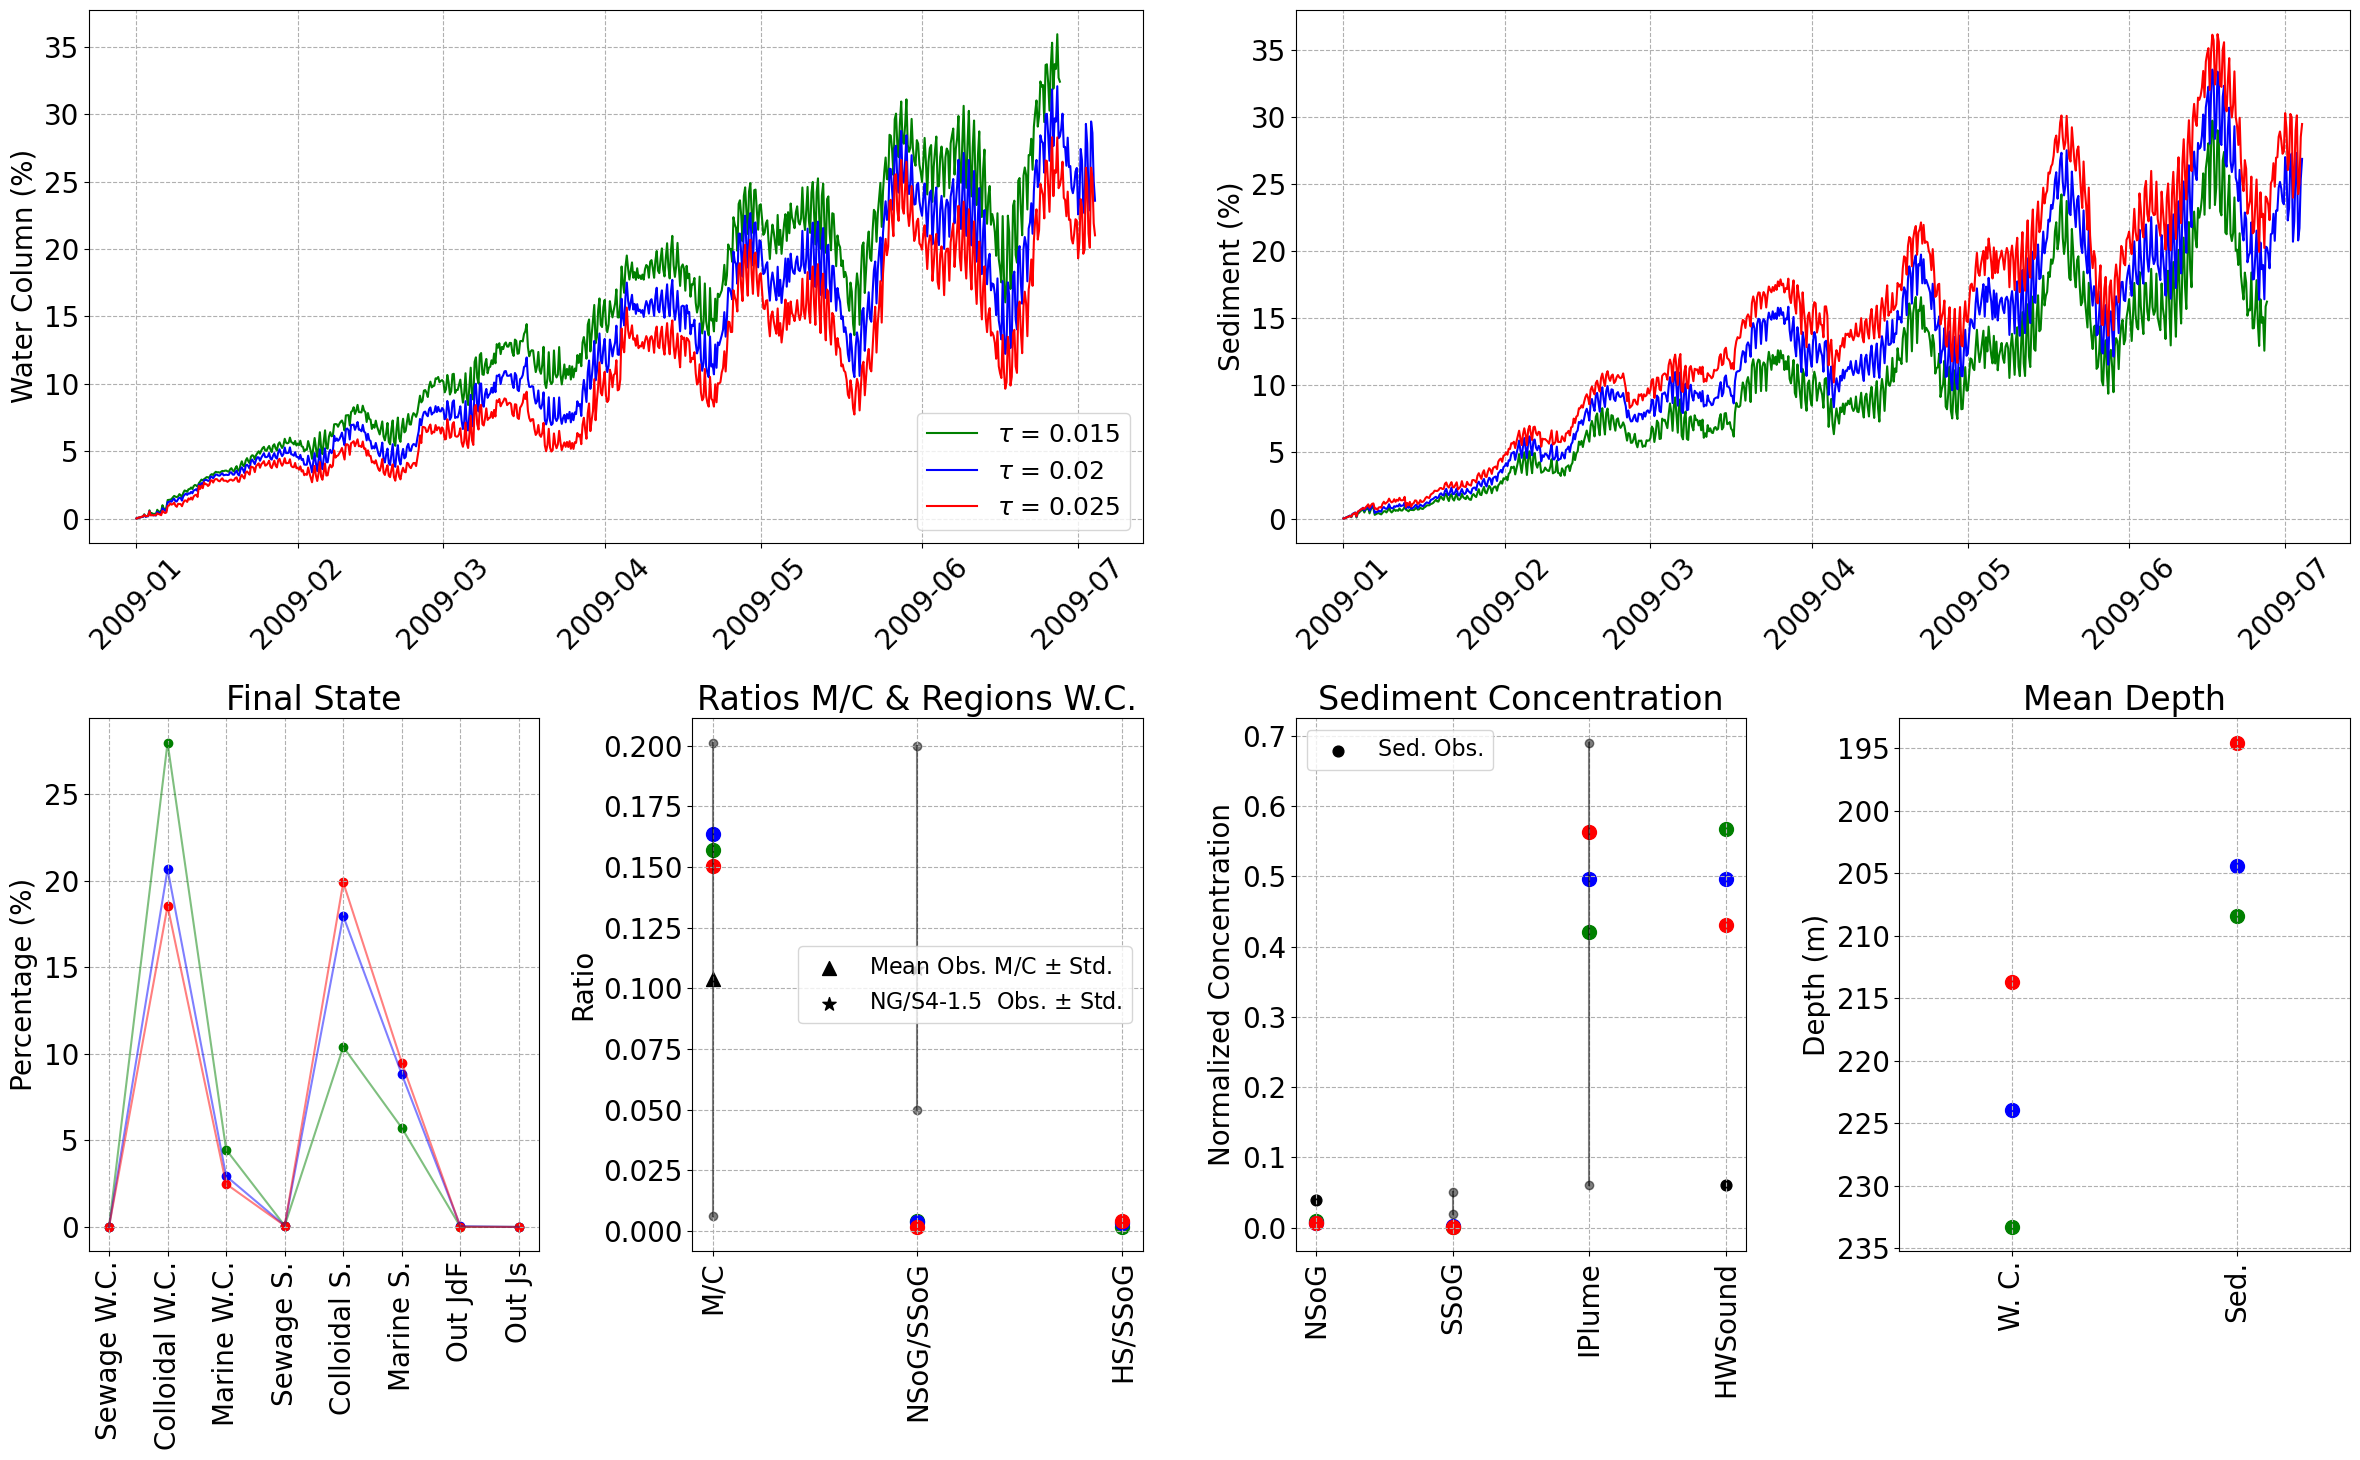

In [40]:
plt.rcParams.update({'font.size': 20})

fig = plt.figure(figsize=(24, 15))
gs = gridspec.GridSpec(2, 8, height_ratios=[1,1])

# === Top row (2 panels) ===
ax1 = fig.add_subplot(gs[0, 0:4])
ax2 = fig.add_subplot(gs[0, 4:8])

# === Middle row (3 panels) ===
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])
ax6 = fig.add_subplot(gs[1, 6:8])
# --- Top left plot (Water Column) ---
ax1.plot(water_tau_0_05, 'g', label=rf'$\tau$ = 0.015')
ax1.plot(water_tau_0_075, 'b', label=rf'$\tau$ = 0.02')
ax1.plot(water_tau_0_1, 'r', label=rf'$\tau$ = 0.025')
ax1.grid(linestyle='--')
ax1.set_ylabel('Water Column (%)')
ax1.legend(loc = 'lower right', fontsize = 18)
ax1.tick_params(axis='x', rotation=45)

# --- Top right plot (Sediment) ---
ax2.plot(sediment_tau_0_05, 'g')
ax2.plot(sediment_tau_0_075, 'b')
ax2.plot(sediment_tau_0_1, 'r')
ax2.grid(linestyle='--')
ax2.set_ylabel('Sediment (%)')
ax2.tick_params(axis='x', rotation=45)

# --- Middle plots ---
# Middle left
ax3.scatter(run_tau_0_05.columns[1:], run_tau_0_05.iloc[-1][1:].values, c='g')
ax3.scatter(run_tau_0_075.columns[1:], run_tau_0_075.iloc[-1][1:].values, c='b')
ax3.scatter(run_tau_0_1.columns[1:], run_tau_0_1.iloc[-1][1:].values, c='r')
#
ax3.plot(run_tau_0_05.columns[1:], run_tau_0_05.iloc[-1][1:].values, color='g', alpha = .5)
ax3.plot(run_tau_0_075.columns[1:], run_tau_0_075.iloc[-1][1:].values, color='b', alpha = .5)
ax3.plot(run_tau_0_1.columns[1:], run_tau_0_1.iloc[-1][1:].values, color='r', alpha = .5)
ax3.grid(linestyle='--')
ax3.tick_params(axis='x', rotation=90)
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Final State')

# Middle center
ratios = [0.27, 0.06, 0.012, 0.011, 0.07, 0.2]
#print(np.mean(ratios))
#print(np.mean(ratios) + np.std(ratios))
#print(np.mean(ratios) - np.std(ratios))
ax4.scatter(table_tau_0_05.columns[1], np.mean(ratios), c='k', marker = '^', s = 100, label = rf'Mean Obs. M/C $\pm$ Std.')
ax4.plot([table_tau_0_05.columns[1], table_tau_0_05.columns[1]], [np.mean(ratios) - np.std(ratios), np.mean(ratios) + np.std(ratios)], '-k', alpha = .5)
ax4.scatter([table_tau_0_05.columns[1], table_tau_0_05.columns[1]], [np.mean(ratios) - np.std(ratios), np.mean(ratios) + np.std(ratios)], c = 'k', marker = 'o', alpha = .5)
#
ax4.scatter(table_tau_0_05.columns[2], 0.108, c='k', marker = '*', s = 100, label = rf'NG/S4-1.5  Obs. $\pm$ Std.')
ax4.plot([table_tau_0_05.columns[2], table_tau_0_05.columns[2]], [0.05, 0.2], '-k', alpha = .5)
ax4.scatter([table_tau_0_05.columns[2], table_tau_0_05.columns[2]], [0.05, 0.2], c = 'k', marker = 'o', alpha = .5)

#
ax4.scatter(table_tau_0_05.columns[[1,2,3]], table_tau_0_05.loc[0].values[[1,2,3]], color='g', s=100)
ax4.scatter(table_tau_0_075.columns[[1,2,3]], table_tau_0_075.loc[0].values[[1,2,3]], color='b', s=100)
ax4.scatter(table_tau_0_1.columns[[1,2,3]], table_tau_0_1.loc[0].values[[1,2,3]], color='r', s=100)
ax4.grid(linestyle='--')
ax4.tick_params(axis='x', rotation=90)
ax4.legend(fontsize = 16)
ax4.set_ylabel('Ratio')
ax4.set_title('Ratios M/C & Regions W.C.')

#
r_labels = ['NSoG', 'SSoG', 'SSoG', 'SSoG', 'IPlume', 'IPlume', 'HWSound']
ax5.scatter(sed_conc_tau_0_05.columns[:], sed_conc_tau_0_05.loc[0].values[:], color='g', s=100)
ax5.scatter(sed_conc_tau_0_075.columns[:], sed_conc_tau_0_075.loc[0].values[:], color='b', s=100)
ax5.scatter(sed_conc_tau_0_1.columns[:], sed_conc_tau_0_1.loc[0].values[:], color='r', s=100)
ax5.scatter(r_labels[0], obsi[0], c='k', marker = 'o', s = 60, label = 'Sed. Obs.') # Median of normalized obs. concentrations
#ax5.scatter(r_labels[1:3], obsi[1:3], c='k', marker = 'o', s = 60) # Median of normalized obs. concentrations
ax5.plot([r_labels[1], r_labels[1]], [np.min(obsi[1:4]), np.max(obsi[1:4])],'-ok', alpha = .5) # Median of normalized obs. concentrations
#ax5.scatter(r_labels[3:5], obsi[3:5], c='k', marker = 'o', s = 60) # Median of normalized obs. concentrations
ax5.plot([r_labels[4], r_labels[5]], [obsi[4], obsi[5]],'-ok', alpha = .5) # Median of normalized obs. concentrations
ax5.scatter(r_labels[6], obsi[5], c='k', marker = 'o', s = 60) # Median of normalized obs. concentrations

ax5.grid(linestyle='--')
ax5.legend(fontsize = 16)
ax5.tick_params(axis='x', rotation=90)
ax5.set_ylabel('Normalized Concentration')
#ax5.set_ylim([0.02, 0.06])
ax5.set_title('Sediment Concentration')


# Middle right
ax6.scatter(table_tau_0_05.columns[-2:], table_tau_0_05.loc[0].values[-2:], color='g', s=100)
ax6.scatter(table_tau_0_075.columns[-2:], table_tau_0_075.loc[0].values[-2:], color='b', s=100)
ax6.scatter(table_tau_0_1.columns[-2:], table_tau_0_1.loc[0].values[-2:], color='r', s=100)
ax6.grid(linestyle='--')
ax6.set_xlim([-.5, 1.5])
ax6.tick_params(axis='x', rotation=90)
ax6.invert_yaxis()
ax6.set_ylabel('Depth (m)')
ax6.set_title('Mean Depth')

#
#
plt.tight_layout()

plt.show()

# What we get in our tests:

In [25]:
data = xr.open_zarr(tau_testing_files[2])
counts_S1 = polygon_definition_data_colloidal(data, polygon_lon_lat_S1)
counts_N1 = polygon_definition_data_colloidal(data, polygon_lon_lat_N1)
#
sum_concentration_S1 = np.sum(counts_S1) / volume_S1
#
sum_concentration_N1 = np.sum(counts_N1) / volume_N1
#
print('Ratio (S1 / N1) new Version', sum_concentration_S1/sum_concentration_N1)

Ratio (S1 / N1) new Version count    208.140531
dtype: float64


/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [16]:
print('Conentration at S1', sum_concentration_S1)

Conentration at S1 count    0.000018
dtype: float64


In [17]:
print('Min Ratio = ', min_ratio)
print('Max Ratio = ', max_ratio)
print('New Testing Ratio = ',  sum_concentration_S1/sum_concentration_N1)

Min Ratio =  count    10.645941
dtype: float64
Max Ratio =  count    39.922279
dtype: float64
New Testing Ratio =  count    72.238857
dtype: float64


In [18]:
print('Target Concentration S1 (Reference 2007) = ', target_concentration)
print('New Concentration S1 = ',  sum_concentration_S1)
print('Target/New', target_concentration/sum_concentration_S1)

Target Concentration S1 (Reference 2007) =  count    0.000573
dtype: float64
New Concentration S1 =  count    0.000018
dtype: float64
Target/New count    31.903485
dtype: float64


In [3]:
0.00001 - 1e-5

0.0

Plots

Required Tau (Linear Model): 0.01034
Required Tau (Quadratic Model): 0.01170


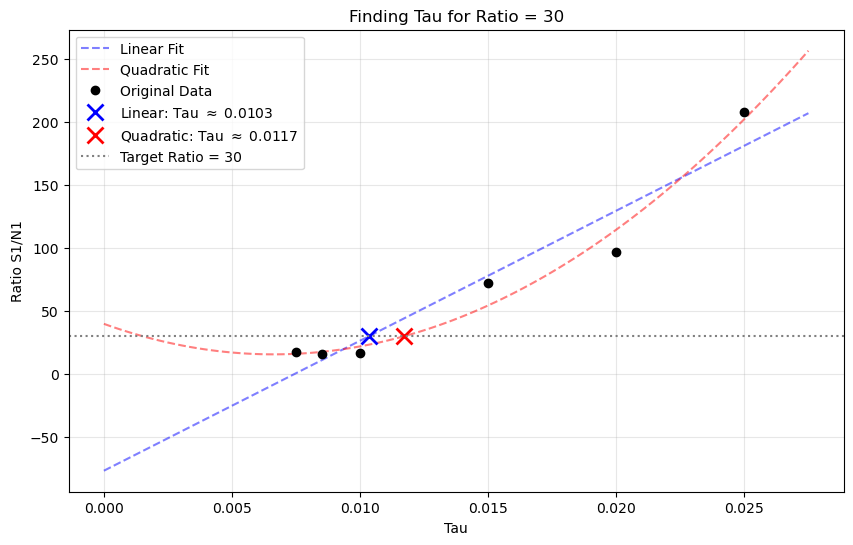

In [ ]:
ratios_S1_N1 = np.array([17.456663, 15.612346, 16.851012, 72.238857, 97.003136, 208.140531])
taus = np.array([0.0075, 0.0085, 0.01, 0.015, 0.02, 0.025])

z1 = np.polyfit(taus, ratios_S1_N1, 1)
p1 = np.poly1d(z1)

z2 = np.polyfit(taus, ratios_S1_N1, 2)
p2 = np.poly1d(z2)

target_ratio = 30

tau_linear = (target_ratio - z1[1]) / z1[0]

roots = (p2 - target_ratio).roots

valid_roots = [r.real for r in roots if np.isreal(r) and r.real > 0]

tau_quad = min(valid_roots, key=lambda x: abs(x - np.mean(taus)))

print(f"Required Tau (Linear Model): {tau_linear:.5f}")
print(f"Required Tau (Quadratic Model): {tau_quad:.5f}")

x_plot = np.linspace(0, max(taus) * 1.1, 100)

plt.figure(figsize=(10, 6))

plt.plot(x_plot, p1(x_plot), 'b--', alpha=0.5, label='Linear Fit')
plt.plot(x_plot, p2(x_plot), 'r--', alpha=0.5, label='Quadratic Fit')
plt.plot(taus, ratios_S1_N1, 'ko', label='Original Data')

plt.plot(tau_linear, target_ratio, 'bx', markersize=12, markeredgewidth=2, 
         label=rf'Linear: Tau $\approx$ {tau_linear:.4f}')
plt.plot(tau_quad, target_ratio, 'rx', markersize=12, markeredgewidth=2, 
         label=rf'Quadratic: Tau $\approx$ {tau_quad:.4f}')

plt.axhline(target_ratio, color='gray', linestyle=':', label=f'Target Ratio = {target_ratio}')

plt.title(f'Finding Tau for S1/N1 Ratio = {target_ratio}')
plt.xlabel('Tau')
plt.ylabel('Ratio S1/N1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
files_ads = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_2_days_tau_0_01.zarr',
             '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_tau_0_01_ads_7_days.zarr',
             '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_Adsorption_20_days.zarr/',
             '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_Adsorption_60_days.zarr',
             '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_Adsorption_100_days.zarr']

In [48]:
data = xr.open_zarr(files_ads[4])
counts_S1 = polygon_definition_data_colloidal(data, polygon_lon_lat_S1)
counts_N1 = polygon_definition_data_colloidal(data, polygon_lon_lat_N1)
#
sum_concentration_S1 = np.sum(counts_S1) / volume_S1
#
sum_concentration_N1 = np.sum(counts_N1) / volume_N1
#
print('Ratio (S1 / N1) new Version', sum_concentration_S1/sum_concentration_N1)
print('Conentration at S1', sum_concentration_S1)

Ratio (S1 / N1) new Version count    2.775324
dtype: float64
Conentration at S1 count    0.00001
dtype: float64


/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Required Ads. (Exponential Model): 0.06959


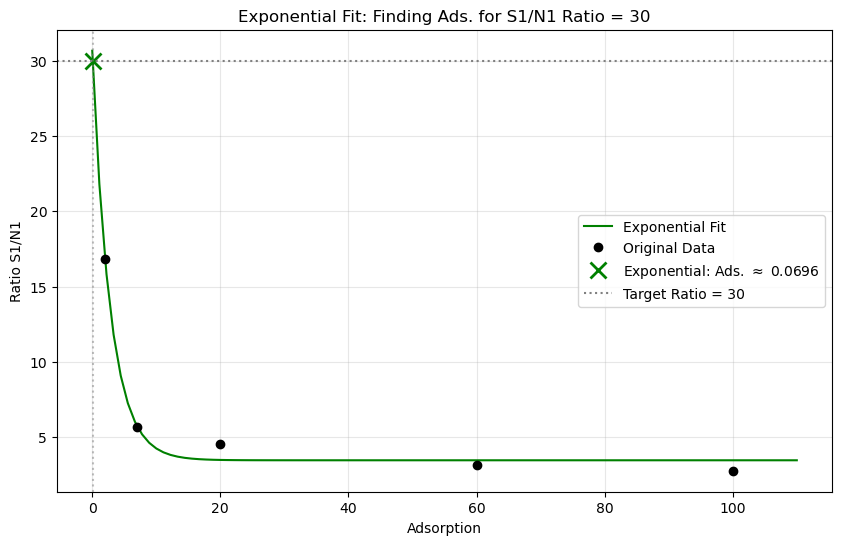

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data
ratios_S1_N1 = np.array([16.851012, 5.701845, 4.539933, 3.14664, 2.775324])
adsorptions = np.array([2, 7, 20, 60, 100])
target_ratio = 30

# Define Exponential Function
def exp_func(x, a, b, c):
    return a * np.exp(b * x) + c

# Fit curve
# Initial guesses based on data shape: decaying (b<0), positive offset (c>0)
popt, pcov = curve_fit(exp_func, adsorptions, ratios_S1_N1, p0=[20, -0.1, 2], maxfev=5000)
a, b, c = popt

# Calculate target adsorption
# 30 = a * e^(b*x) + c  =>  x = ln((30 - c) / a) / b
target_ads = np.log((target_ratio - c) / a) / b

print(f"Required Ads. (Exponential Model): {target_ads:.5f}")

# Plotting
x_plot = np.linspace(0, max(adsorptions) * 1.1, 100)

plt.figure(figsize=(10, 6))

plt.plot(x_plot, exp_func(x_plot, *popt), 'g-', label='Exponential Fit')
plt.plot(adsorptions, ratios_S1_N1, 'ko', label='Original Data')

plt.plot(target_ads, target_ratio, 'gx', markersize=12, markeredgewidth=2, 
         label=rf'Exponential: Ads. $\approx$ {target_ads:.4f}')

plt.axhline(target_ratio, color='gray', linestyle=':', label=f'Target Ratio = {target_ratio}')
# Optional: Vertical line to show x-coordinate
plt.axvline(target_ads, color='gray', linestyle=':', alpha=0.5)

plt.title(f'Exponential Fit: Finding Ads. for S1/N1 Ratio = {target_ratio}')
plt.xlabel('Adsorption')
plt.ylabel('Ratio S1/N1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# use  ads. = 0.5 (at least <1)

# Adsorption: 1, 0.1, 0.01 and 0.001 days & Tau = 0.012

In [34]:
sim_files = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_1_days_tau_0_012.zarr',
             '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_0_1_days_tau_0_012.zarr',
             '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_0_01_days_tau_0_012.zarr',
             '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_0_001_days_tau_0_012.zarr']

In [64]:
data = xr.open_zarr(sim_files[3])
counts_S1 = polygon_definition_data_colloidal(data, polygon_lon_lat_S1)
counts_N1 = polygon_definition_data_colloidal(data, polygon_lon_lat_N1)
#
sum_concentration_S1 = np.sum(counts_S1) / volume_S1
#
sum_concentration_N1 = np.sum(counts_N1) / volume_N1
#
print('Ratio (S1 / N1) new Version', sum_concentration_S1/sum_concentration_N1)
print('Conentration at S1', sum_concentration_S1)

Ratio (S1 / N1) new Version count    1075.42354
dtype: float64
Conentration at S1 count    0.000018
dtype: float64


/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [60]:
new_ratios = [1230.827333, 547.885003, 682.70789, 137.741247]
concentrations = [0.000018, 0.000019, 0.00002,0.000019]
#
ads = [0.001, 0.01, 0.1, 1]

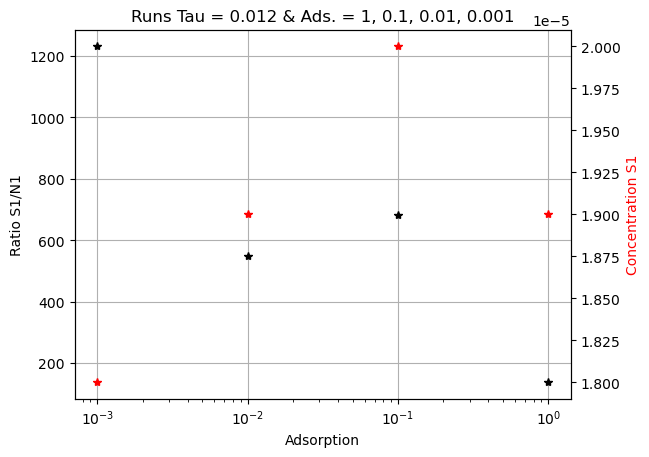

In [63]:
fig, ax = plt.subplots()
ax.plot(ads, new_ratios, '*k')
ax.set_ylabel('Ratio S1/N1')
ax.set_xlabel('Adsorption')
ax.set_xscale('log')
ax1 = ax.twinx()
ax1.plot(ads, concentrations, '*r')
ax1.set_ylabel('Concentration S1', color = 'red')
ax.set_title('Runs Tau = 0.012 & Ads. = 1, 0.1, 0.01, 0.001')
ax.grid()

Fitted Parameters: a=797.8559, b=-4.6737, c=134.0434
Required Ads. (Exponential Model): Unreachable (Asymptote c = 134.04 > 30)


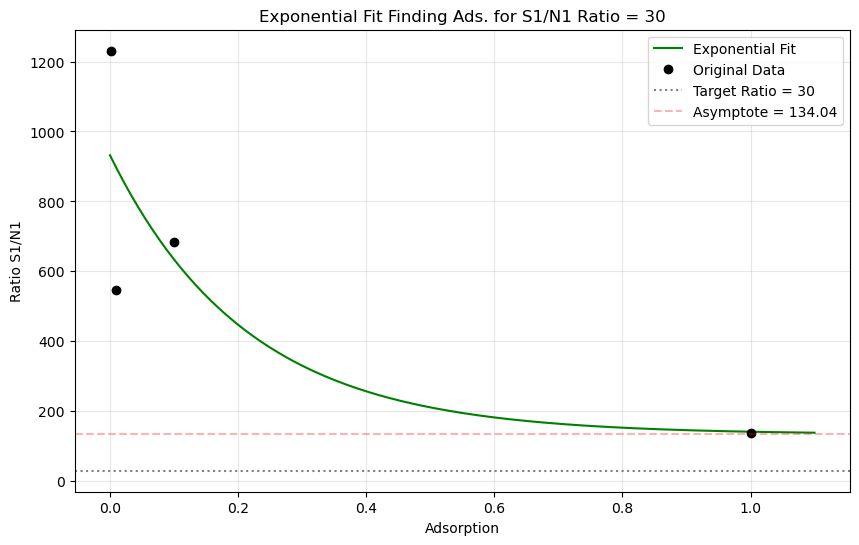

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


target_ratio = 30

def exp_func(x, a, b, c):
    return a * np.exp(b * x) + c

# Fit curve
# Adjusted initial guess (p0) for the larger y-values
# a ~ 1200, b ~ -2, c ~ 100
p0 = [1200, -2, 100] 

try:
    popt, pcov = curve_fit(exp_func, ads, new_ratios, p0=p0, maxfev=10000)
    a, b, c = popt
    print(f"Fitted Parameters: a={a:.4f}, b={b:.4f}, c={c:.4f}")

    # Calculate target adsorption
    # 30 = a * e^(b*x) + c
    if (target_ratio - c) / a > 0:
        target_ads = np.log((target_ratio - c) / a) / b
        print(f"Required Ads. (Exponential Model): {target_ads:.5f}")
    else:
        target_ads = np.nan
        print(f"Required Ads. (Exponential Model): Unreachable (Asymptote c = {c:.2f} > {target_ratio})")

    # Plotting
    x_max = max(ads) * 1.1
    x_plot = np.linspace(0, x_max, 200)

    plt.figure(figsize=(10, 6))
    
    plt.plot(x_plot, exp_func(x_plot, *popt), 'g-', label='Exponential Fit')
    plt.plot(ads, new_ratios, 'ko', label='Original Data')

    if not np.isnan(target_ads):
        plt.plot(target_ads, target_ratio, 'gx', markersize=12, markeredgewidth=2, 
                 label=rf'Target Ads $\approx$ {target_ads:.4f}')
        plt.axvline(target_ads, color='gray', linestyle=':')
    
    plt.axhline(target_ratio, color='gray', linestyle=':', label=f'Target Ratio = {target_ratio}')
    plt.axhline(c, color='red', linestyle='--', alpha=0.3, label=f'Asymptote = {c:.2f}')

    plt.title(f'Exponential Fit Finding Ads. for S1/N1 Ratio = {target_ratio}')
    plt.xlabel('Adsorption')
    plt.ylabel('Ratio S1/N1')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

except Exception as e:
    print(f"Fitting failed: {e}")

Best option? :

- Keep Tau on 0.01
- Ads. between 1 and 2 days

Focus more on S1/N1. Concentration S1 is too far for tunning with just Tau and Ads.

# All Tests

In [ ]:
files_tests = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_2_days_tau_0_015.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_2_days_tau_0_025.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_2_days_tau_0_02.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_0_001_days_tau_0_012.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_0_01_days_tau_0_012.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_0_1_days_tau_0_012.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_1_days_tau_0_012.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_2_days_tau_0_0075.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_2_days_tau_0_0085.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_2_days_tau_0_01.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_tau_0_0075_ads_7_days.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_tau_0_0085_ads_7_days.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_tau_0_01_ads_7_days.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_1_days_tau_0_01_Pa.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_0_5_days_tau_0_0075_Pa.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_0_1_days_tau_0_005_Pa.zarr',
               '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_0_05_days_tau_0_001_Pa.zarr'
               ]

In [6]:
ratios_S1_N1 = []
concentrations_S1 = []
concentrations_N1 = []

In [7]:
for n in files_tests:
    data = xr.open_zarr(n)
    counts_S1 = polygon_definition_data_colloidal(data.isel(obs=slice(-120,None)), polygon_lon_lat_S1)
    counts_N1 = polygon_definition_data_colloidal(data.isel(obs=slice(-120,None)), polygon_lon_lat_N1)
    #
    sum_concentration_S1 = np.sum(counts_S1) / volume_S1
    #
    sum_concentration_N1 = np.sum(counts_N1) / volume_N1
    #
    ratio_S1_N1 = sum_concentration_S1 / sum_concentration_N1
    #
    ratios_S1_N1.append(ratio_S1_N1)
    concentrations_S1.append(sum_concentration_S1)
    concentrations_N1.append(sum_concentration_N1)

/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or 

In [8]:
TAUS = [0.015, 0.025, 0.02, 0.012, 0.012, 0.012, 0.01, 0.012, 0.01, 0.0075, 0.0085, 0.01, 0.01, 0.0075, 0.0085, 0.01, 0.01, 0.0075, 0.005, 0.001]
ADS = [2, 2, 2, 0.001, 0.01, 0.1, 100, 1, 20, 2, 2, 2, 60, 7, 7, 7, 1, 0.5, 0.1, 0.05]

In [9]:
ads_2 = [ADS[0], ADS[1], ADS[2], ADS[9], ADS[10], ADS[11]]
taus_2 = [TAUS[0], TAUS[1], TAUS[2], TAUS[9], TAUS[10], TAUS[11]]
concentrations_S1_2 = [concentrations_S1[0], concentrations_S1[1], concentrations_S1[2], concentrations_S1[9], concentrations_S1[10], concentrations_S1[10]]
ratios_S1_N1_2 = [ratios_S1_N1[0], ratios_S1_N1[1], ratios_S1_N1[2], ratios_S1_N1[9], ratios_S1_N1[10], ratios_S1_N1[10]]
#
ads_7 = [ADS[13], ADS[14], ADS[15]]
taus_7 = [TAUS[13], TAUS[14], TAUS[15]]
concentrations_S1_7 = [concentrations_S1[13], concentrations_S1[14], concentrations_S1[15]]
ratios_S1_N1_7 = [ratios_S1_N1[13], ratios_S1_N1[14] ,ratios_S1_N1[15]]
#
ads_1 = [ADS[7], ADS[16]]
taus_1 = [TAUS[7], TAUS[16]]
concentrations_S1_1 = [concentrations_S1[7], concentrations_S1[16]]
ratios_S1_N1_1 = [ratios_S1_N1[7], ratios_S1_N1[16]]
#
ads_0_1 = [ADS[5], ADS[18]]
taus_0_1 = [TAUS[5], TAUS[18]]
concentrations_S1_0_1 = [concentrations_S1[5], concentrations_S1[18]]
ratios_S1_N1_0_1 = [ratios_S1_N1[5], ratios_S1_N1[18]]

IndexError: list index out of range

In [ ]:
TAUS = [0.015, 0.025, 0.02, 0.012, 0.012, 0.012, 0.01, 0.012, 0.01, 0.0075, 0.0085, 0.01, 0.01, 0.0075, 0.0085, 0.01, 0.01, 0.0075, 0.005, 0.001]
ADS = [2, 2, 2, 0.001, 0.01, 0.1, 100, 1, 20, 2, 2, 2, 60, 7, 7, 7, 1, 0.5, 0.1, 0.05]

Text(0.5, 0, 'Tau ($\\tau$)')

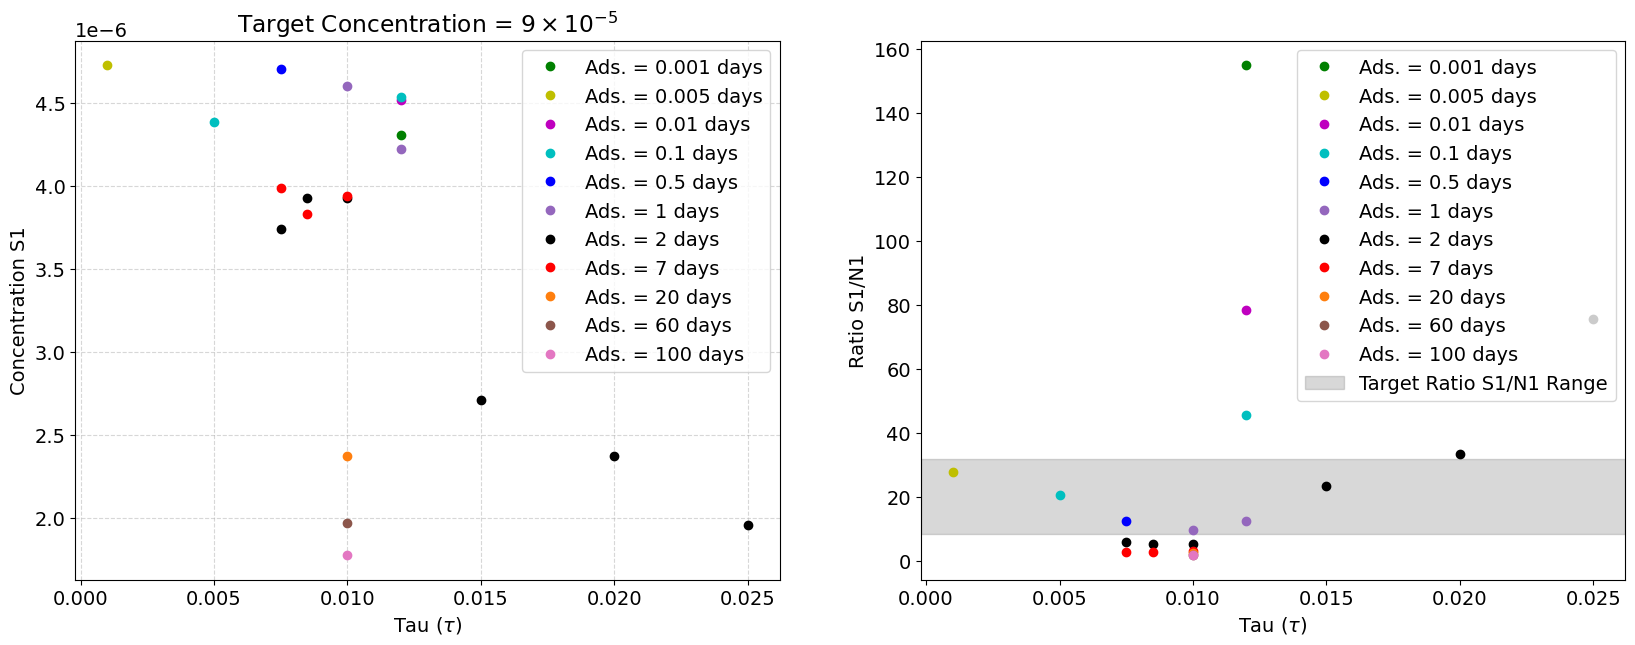

In [ ]:
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1,2, figsize = (20,7))
ax[0].plot(TAUS[3], concentrations_S1[3], 'og', label = 'Ads. = 0.001 days')
ax[0].plot(TAUS[19], concentrations_S1[19], 'oy', label = 'Ads. = 0.005 days')
ax[0].plot(TAUS[4], concentrations_S1[4], 'om', label = 'Ads. = 0.01 days')
ax[0].plot(taus_0_1, concentrations_S1_0_1, 'oc', label = 'Ads. = 0.1 days')
ax[0].plot(TAUS[17], concentrations_S1[17], 'ob', label = 'Ads. = 0.5 days')
ax[0].plot(taus_1, concentrations_S1_1, 'o', color = 'tab:purple', label = 'Ads. = 1 days')
ax[0].plot(taus_2, concentrations_S1_2, 'ok', label = 'Ads. = 2 days')
ax[0].plot(taus_7, concentrations_S1_7, 'or', label = 'Ads. = 7 days')
ax[0].grid(linestyle='--', alpha = .5)
#
ax[0].legend()
ax[0].set_title(r'Target Concentration = $9 \times 10^{-5}$')
ax[0].set_ylabel('Concentration S1')
ax[0].set_xlabel(r'Tau ($\tau$)')

#
ax[1].plot(TAUS[3], ratios_S1_N1[3], 'og', label = 'Ads. = 0.001 days')
ax[1].plot(TAUS[19], ratios_S1_N1[19], 'oy', label = 'Ads. = 0.005 days')
ax[1].plot(TAUS[4], ratios_S1_N1[4], 'om', label = 'Ads. = 0.01 days')
ax[1].plot(taus_0_1, ratios_S1_N1_0_1, 'oc', label = 'Ads. = 0.1 days')
ax[1].plot(TAUS[17], ratios_S1_N1[17], 'ob', label = 'Ads. = 0.5 days')
ax[1].plot(taus_1, ratios_S1_N1_1, 'o', color = 'tab:purple', label = 'Ads. = 1 days')
ax[1].plot(taus_2, ratios_S1_N1_2, 'ok', label = 'Ads. = 2 days')
ax[1].plot(taus_7, ratios_S1_N1_7, 'or', label = 'Ads. = 7 days')
ax[1].axhspan(8.5, 31.8, color='gray', alpha=0.3, label = 'Target Ratio S1/N1 Range')
ax[1].legend()
ax[1].set_ylabel('Ratio S1/N1')
ax[1].set_xlabel(r'Tau ($\tau$)')

# Try with lower sinking velocities

In [5]:
low_sink_tests = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_Low_sink_ads_0_001_tau_0_005.zarr',
                  '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_Low_sink_ads_0_01_tau_0_005.zarr',
                  '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_Low_sink_ads_0_05_tau_0_0075.zarr',
                  '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_Low_sink_ads_0_1_tau_0_01.zarr'
               ]

In [6]:
ratios_S1_N1 = []
concentrations_S1 = []
concentrations_N1 = []
for n in low_sink_tests:
    data = xr.open_zarr(n)
    counts_S1 = polygon_definition_data_colloidal(data.isel(obs=slice(-120,None)), polygon_lon_lat_S1)
    counts_N1 = polygon_definition_data_colloidal(data.isel(obs=slice(-120,None)), polygon_lon_lat_N1)
    #
    sum_concentration_S1 = np.sum(counts_S1) / volume_S1
    #
    sum_concentration_N1 = np.sum(counts_N1) / volume_N1
    #
    ratio_S1_N1 = sum_concentration_S1 / sum_concentration_N1
    #
    ratios_S1_N1.append(ratio_S1_N1)
    concentrations_S1.append(sum_concentration_S1)
    concentrations_N1.append(sum_concentration_N1)

/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [7]:
TAUS = [0.005, 0.005, 0.0075, 0.01]
ADS = [0.001, 0.01, 0.05, 0.1]

In [8]:
ratios_S1_N1

[count    1.005686
 dtype: float64,
 count    0.967921
 dtype: float64,
 count    1.01799
 dtype: float64,
 count    1.008384
 dtype: float64]

Text(0.5, 0.98, 'Sinking velocities lowered by x10')

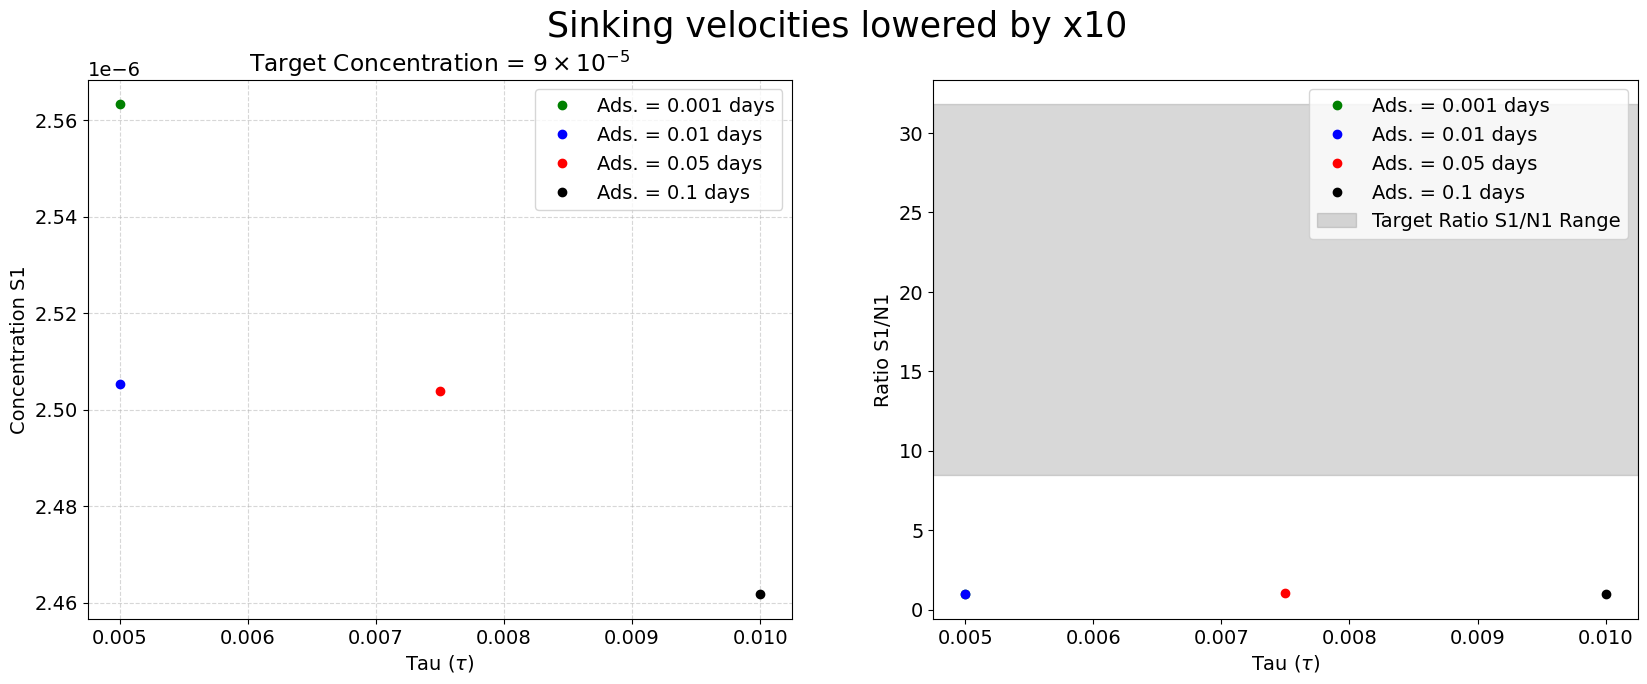

In [9]:
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1,2, figsize = (20,7))
ax[0].plot(TAUS[0], concentrations_S1[0], 'og', label = 'Ads. = 0.001 days')
ax[0].plot(TAUS[1], concentrations_S1[1], 'ob', label = 'Ads. = 0.01 days')
ax[0].plot(TAUS[2], concentrations_S1[2], 'or', label = 'Ads. = 0.05 days')
ax[0].plot(TAUS[3], concentrations_S1[3], 'ok', label = 'Ads. = 0.1 days')

ax[0].grid(linestyle='--', alpha = .5)
#
ax[0].legend()
ax[0].set_title(r'Target Concentration = $9 \times 10^{-5}$')
ax[0].set_ylabel('Concentration S1')
ax[0].set_xlabel(r'Tau ($\tau$)')

#
ax[1].plot(TAUS[0], ratios_S1_N1[0], 'og', label = 'Ads. = 0.001 days')
ax[1].plot(TAUS[1], ratios_S1_N1[1], 'ob', label = 'Ads. = 0.01 days')
ax[1].plot(TAUS[2], ratios_S1_N1[2], 'or', label = 'Ads. = 0.05 days')
ax[1].plot(TAUS[3], ratios_S1_N1[3], 'ok', label = 'Ads. = 0.1 days')


ax[1].axhspan(8.5, 31.8, color='gray', alpha=0.3, label = 'Target Ratio S1/N1 Range')
ax[1].legend()
ax[1].set_ylabel('Ratio S1/N1')
ax[1].set_xlabel(r'Tau ($\tau$)')
plt.suptitle('Sinking velocities lowered by x10', fontsize = 25)

# Keep S.Vel, ads. and Tau, but Decrease the MC ratio

In [5]:
files_MC = ['/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_MC_0_01_ads_0_1_tau_0_005.zarr',
            '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_MC_0_05_ads_0_1_tau_0_005.zarr',
            '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_MC_0_1_ads_0_1_tau_0_005.zarr',
            '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_MC_0_15_ads_0_1_tau_0_005.zarr']

In [16]:
ratios_S1_N1 = []
concentrations_S1 = []
concentrations_N1 = []
for n in files_MC:
    data = xr.open_zarr(n, drop_variables=['H_vel_2', 'bat_particle', 'crit', 'fact','fmask','e3t','totaldepth', 'uvalue','vvalue','wvalue'])
    counts_S1 = polygon_definition_data_colloidal(data.isel(obs=slice(-120,None)), polygon_lon_lat_S1)
    counts_N1 = polygon_definition_data_colloidal(data.isel(obs=slice(-120,None)), polygon_lon_lat_N1)
    #
    sum_concentration_S1 = np.sum(counts_S1) / volume_S1
    #
    sum_concentration_N1 = np.sum(counts_N1) / volume_N1
    #
    ratio_S1_N1 = sum_concentration_S1 / sum_concentration_N1
    #
    ratios_S1_N1.append(ratio_S1_N1)
    concentrations_S1.append(sum_concentration_S1)
    concentrations_N1.append(sum_concentration_N1)

/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/vicentev/conda_envs/Parcels/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or 

In [17]:
TAUS = [0.005, 0.005, 0.005, 0.005]
ADS = [0.1, 0.1, 0.1, 0.1]

Text(0.5, 0.98, 'Changes in MC ratio - Adsorption fixed to 0.1 days')

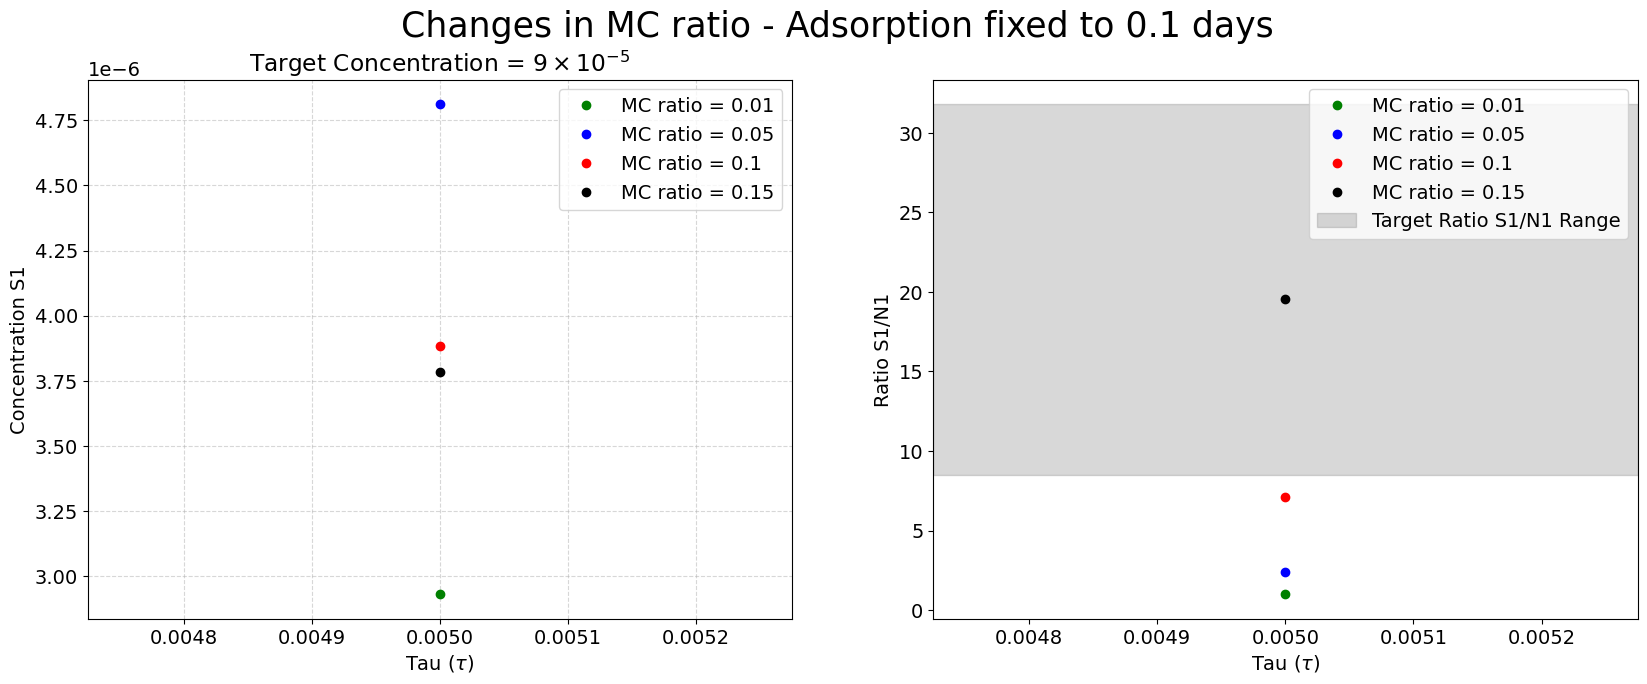

In [19]:
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1,2, figsize = (20,7))
ax[0].plot(TAUS[0], concentrations_S1[0], 'og', label = 'MC ratio = 0.01')
ax[0].plot(TAUS[1], concentrations_S1[1], 'ob', label = 'MC ratio = 0.05')
ax[0].plot(TAUS[2], concentrations_S1[2], 'or', label = 'MC ratio = 0.1')
ax[0].plot(TAUS[3], concentrations_S1[3], 'ok', label = 'MC ratio = 0.15')

ax[0].grid(linestyle='--', alpha = .5)
#
ax[0].legend()
ax[0].set_title(r'Target Concentration = $9 \times 10^{-5}$')
ax[0].set_ylabel('Concentration S1')
ax[0].set_xlabel(r'Tau ($\tau$)')

#
ax[1].plot(TAUS[0], ratios_S1_N1[0], 'og', label = 'MC ratio = 0.01')
ax[1].plot(TAUS[1], ratios_S1_N1[1], 'ob', label = 'MC ratio = 0.05')
ax[1].plot(TAUS[2], ratios_S1_N1[2], 'or', label = 'MC ratio = 0.1')
ax[1].plot(TAUS[3], ratios_S1_N1[3], 'ok', label = 'MC ratio = 0.15')


ax[1].axhspan(8.5, 31.8, color='gray', alpha=0.3, label = 'Target Ratio S1/N1 Range')
ax[1].legend()
ax[1].set_ylabel('Ratio S1/N1')
ax[1].set_xlabel(r'Tau ($\tau$)')
plt.suptitle('Changes in MC ratio - Adsorption fixed to 0.1 days', fontsize = 25)

Convert all to netcdf to keep files but make more space for the long run

In [ ]:
all_files = [
    #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_2_days_tau_0_015.zarr',
    #           '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_2_days_tau_0_025.zarr',
    #           '/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_2_days_tau_0_02.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_0_001_days_tau_0_012.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_0_01_days_tau_0_012.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_0_1_days_tau_0_012.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_1_days_tau_0_012.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_2_days_tau_0_0075.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_2_days_tau_0_0085.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_adsorption_2_days_tau_0_01.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_tau_0_0075_ads_7_days.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_tau_0_0085_ads_7_days.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_tau_0_01_ads_7_days.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_1_days_tau_0_01_Pa.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_0_5_days_tau_0_0075_Pa.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_0_1_days_tau_0_005_Pa.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_ads_0_05_days_tau_0_001_Pa.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_Low_sink_ads_0_001_tau_0_005.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_Low_sink_ads_0_01_tau_0_005.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_Low_sink_ads_0_05_tau_0_0075.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_Low_sink_ads_0_1_tau_0_01.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_MC_0_01_ads_0_1_tau_0_005.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_MC_0_05_ads_0_1_tau_0_005.zarr',
               #'/home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_MC_0_15_ads_0_1_tau_0_005.zarr'
               ]

In [5]:
import xarray as xr
import os

for zarr_path in all_files:

    # Check if the zarr file exists
    if not os.path.exists(zarr_path):
        print(f"Skipping (not found): {zarr_path}")
        continue

    print(f"Processing: {zarr_path}")

    # Open zarr dataset
    ds = xr.open_zarr(zarr_path)

    # Create output NetCDF path
    nc_path = os.path.splitext(zarr_path)[0] + ".nc"

    # Save as NetCDF
    ds.to_netcdf(nc_path)

    ds.close()

    print(f"Saved: {nc_path}")

Processing: /home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_MC_0_15_ads_0_1_tau_0_005.zarr
Saved: /home/vicentev/scratch/vicentev/Tuning_outputs/PBDEs_0112009_run_365_days_MC_0_15_ads_0_1_tau_0_005.nc
